In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# 載入訓練集和測試集，並確認資料正確
train_df = pd.read_csv('data/mitbih_train.csv')
test_df = pd.read_csv('data/mitbih_test.csv')
print(train_df.head(2))
print(test_df.head(2))

   9.779411554336547852e-01  9.264705777168273926e-01  \
0                  0.960114                  0.863248   
1                  1.000000                  0.659459   

   6.813725233078002930e-01  2.450980395078659058e-01  \
0                  0.461538                  0.196581   
1                  0.186486                  0.070270   

   1.544117629528045654e-01  1.911764740943908691e-01  \
0                  0.094017                  0.125356   
1                  0.070270                  0.059459   

   1.519607901573181152e-01  8.578431606292724609e-02  \
0                  0.099715                  0.088319   
1                  0.056757                  0.043243   

   5.882352963089942932e-02  4.901960864663124084e-02  ...  \
0                  0.074074                  0.082621  ...   
1                  0.054054                  0.045946  ...   

   0.000000000000000000e+00.79  0.000000000000000000e+00.80  \
0                          0.0                          0.0   

In [7]:
# 顯示訓練集的欄位資訊、資料型態與缺失值狀況
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87553 entries, 0 to 87552
Columns: 188 entries, 9.779411554336547852e-01 to 0.000000000000000000e+00.88
dtypes: float64(188)
memory usage: 125.6 MB
None


In [8]:
# 顯示訓練集各欄位的統計摘要（平均值、標準差、最大最小值等）
print(train_df.describe())

       9.779411554336547852e-01  9.264705777168273926e-01  \
count              87553.000000              87553.000000   
mean                   0.890359                  0.758158   
std                    0.240910                  0.221814   
min                    0.000000                  0.000000   
25%                    0.921922                  0.682482   
50%                    0.991342                  0.826007   
75%                    1.000000                  0.910506   
max                    1.000000                  1.000000   

       6.813725233078002930e-01  2.450980395078659058e-01  \
count              87553.000000              87553.000000   
mean                   0.423969                  0.219104   
std                    0.227305                  0.206880   
min                    0.000000                  0.000000   
25%                    0.250965                  0.048458   
50%                    0.429467                  0.165992   
75%                    

In [9]:
# 確認訓練集各欄位缺失值數量（全為 0 代表無缺失值）
print(train_df.isnull().sum())

9.779411554336547852e-01       0
9.264705777168273926e-01       0
6.813725233078002930e-01       0
2.450980395078659058e-01       0
1.544117629528045654e-01       0
                              ..
0.000000000000000000e+00.84    0
0.000000000000000000e+00.85    0
0.000000000000000000e+00.86    0
0.000000000000000000e+00.87    0
0.000000000000000000e+00.88    0
Length: 188, dtype: int64


In [10]:
# 確認測試集各欄位缺失值數量
print(test_df.isna().sum())

1.000000000000000000e+00       0
7.582644820213317871e-01       0
1.115702465176582336e-01       0
0.000000000000000000e+00       0
8.057851344347000122e-02       0
                              ..
0.000000000000000000e+00.61    0
0.000000000000000000e+00.62    0
0.000000000000000000e+00.63    0
0.000000000000000000e+00.64    0
0.000000000000000000e+00.65    0
Length: 188, dtype: int64


In [11]:
# 切分訓練集：X 為 187 個 ECG 訊號，y 為心律類別標籤（0~4）
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

# 切分測試集
X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

In [12]:
# 標準化：用訓練集的 mean/std 縮放，測試集套用相同參數避免資料洩漏
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 新增通道維度，符合 1D-CNN 輸入格式 (筆數, 序列長度, 通道數)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.utils import to_categorical

In [18]:
# 處理標籤中的 NaN：先標記為 -1，再過濾掉，確保標籤有效
y_train_cleaned = np.nan_to_num(y_train, nan=-1)
y_test_cleaned = np.nan_to_num(y_test, nan=-1)

y_train_filtered = y_train_cleaned[y_train_cleaned != -1]
y_test_filtered = y_test_cleaned[y_test_cleaned != -1]

# 將類別標籤轉成 one-hot 編碼（5種心律）
y_train_cat = to_categorical(y_train_filtered)
y_test_cat = to_categorical(y_test_filtered)

In [19]:
# 過濾掉對應標籤為 NaN 的 X 資料，確保 X 和 y 筆數一致
X_train_filtered = X_train[y_train_cleaned != -1]

# 切分訓練集（80% 訓練，20% 驗證）
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_filtered, y_train_cat, test_size=0.2, random_state=42)

In [20]:
print(X_train.shape)
print(y_train_cat.shape)

(87553, 187, 1)
(87553, 5)


## 模型建立與訓練

使用 1D-CNN 對 ECG 時序訊號進行多分類，辨識 5 種心律類型。

In [21]:
# 取得類別數量（5種心律）
num_classes = y_train_cat.shape[1]

# 建立 1D-CNN 模型
model = models.Sequential([
    # 第一層卷積：32個濾鏡，找出 ECG 基本波形特徵
    layers.Conv1D(32, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], 1)),
    layers.MaxPooling1D(pool_size=2),  # 縮小序列長度一半

    # 第二層卷積：64個濾鏡，學習更複雜的特徵
    layers.Conv1D(64, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(pool_size=2),  # 再縮小一半

    layers.BatchNormalization(),        # 正規化
    layers.Flatten(),                   # 攤平成一維

    layers.Dense(128, activation='relu'),  # 全連接層，整合特徵
    layers.Dropout(0.5),                   # 隨機關閉 50% 神經元，防止過擬合
    layers.Dense(num_classes, activation='softmax')  # 輸出 5 種心律的機率
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 43, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2752)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       352,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,781 (1.39 MB)

 Trainable params: 363,653 (1.39 MB)

 Non-trainable params: 128 (512.00 B)

In [22]:
# 編譯模型：設定優化器、損失函數和評估指標
model.compile(
    optimizer='adam',                  # 優化器：自動調整學習率
    loss='categorical_crossentropy',   # 多分類損失函數（搭配 one-hot 標籤）
    metrics=['accuracy']               # 訓練時顯示準確率
)

In [24]:
# 訓練模型：訓練資料
history = model.fit(
    X_train_final, y_train_final,   # 訓練資料（80%）
    epochs=20,                      # 訓練輪數
    batch_size=64,                  # 每批次筆數
    validation_data=(X_val, y_val), # 驗證集（20%）
    verbose=1                       # 顯示訓練進度
)

Epoch 1/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - accuracy: 0.9498 - loss: 0.1958 - val_accuracy: 0.9724 - val_loss: 0.0976
Epoch 2/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - accuracy: 0.9725 - loss: 0.1017 - val_accuracy: 0.9766 - val_loss: 0.0829
Epoch 3/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 32s 29ms/step - accuracy: 0.9767 - loss: 0.0826 - val_accuracy: 0.9781 - val_loss: 0.0781
Epoch 4/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9791 - loss: 0.0711 - val_accuracy: 0.9788 - val_loss: 0.0810
Epoch 5/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 31s 29ms/step - accuracy: 0.9817 - loss: 0.0632 - val_accuracy: 0.9809 - val_loss: 0.0657
Epoch 6/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 45s 41ms/step - accuracy: 0.9835 - loss: 0.0549 - val_accuracy: 0.9826 - val_loss: 0.0735
Epoch 7/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - accuracy: 0.9845 - loss: 0.0488 - val_accuracy: 0.9845 - val_loss: 0.0646
Epoch 8/20
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step - accuracy: 0.9852 -

## 模型評估結果

In [25]:
# 對測試集預測，輸出每種心律的機率值
y_pred_prob = model.predict(X_test)

# 取機率最高的類別作為預測結果
y_pred = y_pred_prob.argmax(axis=1)

# 實際標籤（來自測試集的原始類別，0~4）
y_true = y_test

685/685 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step


In [26]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 將 y_true 中的 NaN 換成 0，避免評估時報錯
y_true = np.nan_to_num(y_true, nan=0)

# 輸出每個心律類別分類報告，以及整體準確率
print("classification report -> ", classification_report(y_true, y_pred))
print("accuracy score -> ", accuracy_score(y_true, y_pred))

classification report ->                precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     18117
         1.0       0.90      0.78      0.83       556
         2.0       0.96      0.96      0.96      1448
         3.0       0.90      0.73      0.81       162
         4.0       0.99      0.98      0.99      1608

    accuracy                           0.98     21891
   macro avg       0.95      0.89      0.92     21891
weighted avg       0.98      0.98      0.98     21891

accuracy score ->  0.9847425882782879


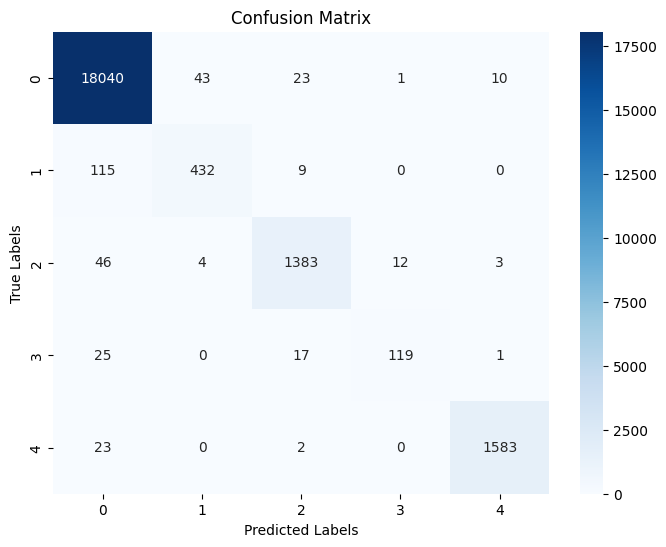

In [28]:
# 混淆矩陣：測試集的預測表現（5種心律的預測結果分布）
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,
    annot=True,   # 顯示數字
    fmt='d',      # 整數格式
    cmap='Blues'
)
plt.xlabel('Predicted Labels')  # X 軸：預測類別
plt.ylabel('True Labels')       # Y 軸：實際類別
plt.title('Confusion Matrix')
plt.show()

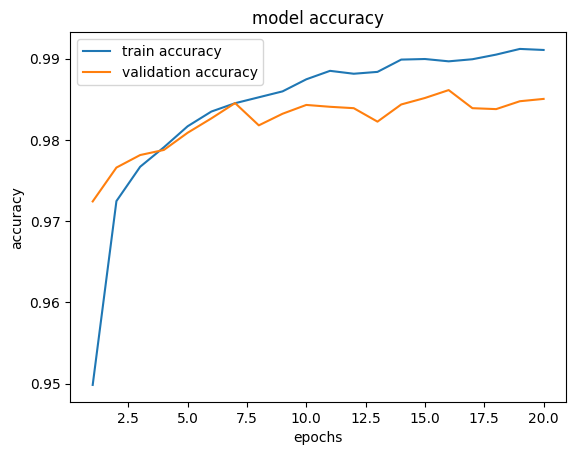

In [29]:
# 畫出訓練集 vs 驗證集的準確率變化曲線
epochs = range(1, len(history.history['accuracy']) + 1)
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

plt.plot(epochs, train_accuracy, label="train accuracy")
plt.plot(epochs, val_accuracy, label="validation accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("model accuracy")
plt.legend()
plt.show()


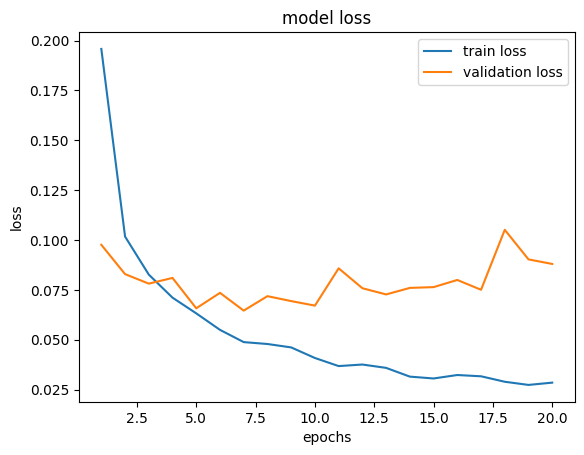

In [30]:
# 畫出訓練集 vs 驗證集的損失值變化曲線
epochs = range(1, len(history.history['loss']) + 1)
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, train_loss, label="train loss")
plt.plot(epochs, val_loss, label="validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("model loss")
plt.legend()
plt.show()